In [18]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

 - https://stackoverflow.com/questions/79859000/what-scipy-function-to-use-to-estimate-this-2d-problem-with-rotation-translatio

In [19]:
UV = np.array([
    (100,200),
    (100,220),
    (100,240),
    (100,260),
    (100,280),
    (150,200),
    (150,220),
    (150,240),
    (150,260),
    (150,280),
])

In [20]:
XYS = np.array([
    (-79055.6, -108720.7, 1.0),
    (-81032.2, -122577.8, 2.7),
    (-83007.5, -136440.7, 0.5),
    (-84980.8, -150304.5, 4.9),
    (-86964.5, -164160.7, 7.2),
    (-113710.4, -103788.9, 8.6),
    (-115682.6, -117643.3, 4.5),
    (-117657.9, -131497.5, 3.7),
    (-119632.2, -145362.1, 2.6),
    (-121610.9, -159218.0, 3.5),
])

In [21]:
xl, yl = (10000.0, 20000.0)
c = 700.00
a = 3.000

In [22]:
def model(uv, xl, yl, c, a):
    return np.hstack([
        xl + uv[:,0] * c * np.cos(a) - uv[:,1] * c * np.sin(a),
        yl + uv[:,0] * c * np.sin(a) + uv[:,1] * c * np.cos(a)
    ])

In [23]:
XY = np.hstack([XYS[:,0], XYS[:,1]])
XY

array([ -79055.6,  -81032.2,  -83007.5,  -84980.8,  -86964.5, -113710.4,
       -115682.6, -117657.9, -119632.2, -121610.9, -108720.7, -122577.8,
       -136440.7, -150304.5, -164160.7, -103788.9, -117643.3, -131497.5,
       -145362.1, -159218. ])

In [24]:
S = np.hstack([XYS[:,2], XYS[:,2]])

In [25]:
popt, pcov = optimize.curve_fit(model, UV, XY, p0=[1000, 2000, 700, 3], sigma=S, absolute_sigma=True)

In [26]:
popt, pcov

(array([1.00039201e+04, 1.99996452e+04, 7.00007347e+02, 2.99998187e+00]),
 array([[ 2.57493384e+01,  3.22860561e-07,  5.30486985e-02,
         -1.21374051e-04],
        [ 3.22860561e-07,  2.57493371e+01,  8.49627193e-02,
          7.57830508e-05],
        [ 5.30486985e-02,  8.49627193e-02,  3.92373308e-04,
         -3.70561323e-14],
        [-1.21374051e-04,  7.57830508e-05, -3.70561323e-14,
          8.00745099e-10]]))

In [27]:
np.sqrt(np.diag(pcov))

array([5.07438059e+00, 5.07438047e+00, 1.98084151e-02, 2.82974398e-05])

In [28]:
XYhat = model(UV, *popt)

In [29]:
residuals = (XY - XYhat).reshape(XYS[:,:2].shape)

In [30]:
residuals

array([[ 0.0245148 , -0.62332629],
       [ 0.02883261,  2.68099152],
       [-5.06684958, -4.76399398],
       [-1.01183508, -0.35967617],
       [ 1.29248273, -1.45535837],
       [-0.05999931,  2.84459718],
       [-0.05080634, -3.84620985],
       [-0.04161337, -8.14039657],
       [-2.53580008,  3.2687964 ],
       [-1.32660711,  2.77798937]])

In [63]:
ulin = np.linspace(UV[:,0].min(), UV[:,0].max(), 20)
vlin = np.linspace(UV[:,1].min(), UV[:,1].max(), 20)
U, V = np.meshgrid(ulin, vlin)

In [64]:
UVlin = np.vstack([U.ravel(), V.ravel()]).T

In [78]:
XYlin = model(UVlin, *popt).reshape((2, U.size)).T

In [83]:
X = XYlin[:,0].reshape(U.shape)
Y = XYlin[:,1].reshape(U.shape)

Text(0.5, 0, '$x(u,v)$')

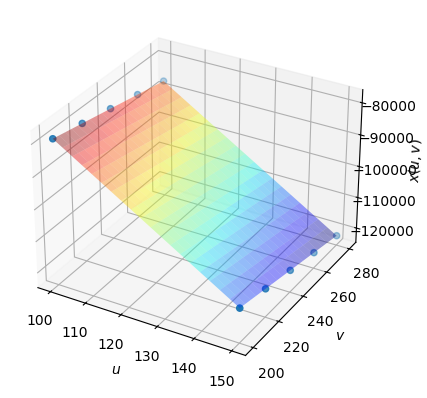

In [89]:
fig, axe = plt.subplots(subplot_kw={"projection": "3d"})
axe.scatter(*UV.T, XYS[:,0])
axe.plot_surface(U, V, X, cmap="jet", alpha=0.4)
axe.set_xlabel("$u$")
axe.set_ylabel("$v$")
axe.set_zlabel("$x(u,v)$")

Text(0.5, 0, '$z$')

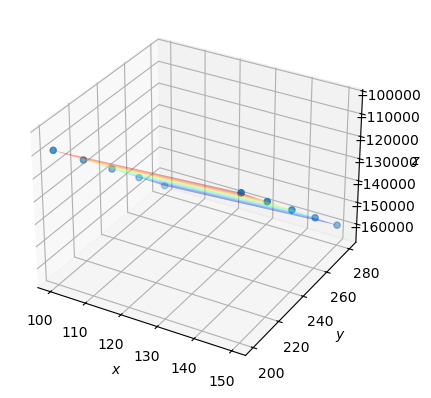

In [88]:
fig, axe = plt.subplots(subplot_kw={"projection": "3d"})
axe.scatter(*UV.T, XYS[:,1])
axe.plot_surface(U, V, Y, cmap="jet", alpha=0.4)
axe.set_xlabel("$x$")
axe.set_ylabel("$y$")
axe.set_zlabel("$z$")